In [1]:
import sys
import os
import warnings
import numpy as np
import mne
import matplotlib.pyplot as plt

from scipy.signal import welch
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

print(sys.executable)
print("all imports successful")

/usr/local/bin/python3.14
all imports successful


In [2]:
# -----------------------------
# 1. 配置
# -----------------------------
DATA_DIR = "/Users/gefeizhang/Downloads/MAIS"   # 改成你的真实文件夹路径

FS = 256
LOW_HZ = 0.5
HIGH_HZ = 25.0

WINDOW_SEC = 2                 # Shoeb paper uses 2-second epochs
WINDOW_SAMPLES = FS * WINDOW_SEC
STACK_W = 3                    # stack 3 windows -> 6 seconds context
TRAIN_ONSET_ONLY_SEC = 20      # only keep first 20 s after seizure onset
USE_ONLY_FIRST_18_CHANNELS = True

# file_info: key必须是 .edf，不是 .edf.seizures
file_info = {
    "chb01_01.edf": [],
    "chb01_03.edf": [(2996, 3036)],
    "chb01_04.edf": [(1467, 1494)],
    "chb01_05.edf": [],
    "chb01_15.edf": [(1732, 1772)],
    "chb01_16.edf": [(1015, 1066)],
    "chb01_17.edf": [],
    "chb01_20.edf": [],
}

# 训练集：3 seizure + 3 non-seizure
train_files = [
    "chb01_01.edf",
    "chb01_05.edf",
    "chb01_17.edf",
    "chb01_04.edf",
    "chb01_15.edf",
    "chb01_16.edf",
]

# 测试集：1 seizure + 1 non-seizure
test_files = [
    "chb01_03.edf",
    "chb01_20.edf",
]

# 8 equal-width bands between 0.5 and 25 Hz
band_edges = np.linspace(LOW_HZ, HIGH_HZ, 9)
print("Band edges:", band_edges)

Band edges: [ 0.5     3.5625  6.625   9.6875 12.75   15.8125 18.875  21.9375 25.    ]


In [3]:
# -----------------------------
# 2. 读EDF
# -----------------------------
def load_raw_edf(path):
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="Channel names are not unique*"
        )
        raw = mne.io.read_raw_edf(path, preload=True, verbose=False)

    raw.filter(l_freq=LOW_HZ, h_freq=HIGH_HZ, verbose=False)

    if USE_ONLY_FIRST_18_CHANNELS:
        raw.pick(raw.ch_names[:18])

    return raw

In [4]:
# -----------------------------
# 3. 单个2秒窗 -> 频带能量特征
# -----------------------------
def band_energy_features(epoch_2s, fs=FS, band_edges=band_edges):
    feats = []

    for ch in range(epoch_2s.shape[0]):
        freqs, psd = welch(epoch_2s[ch], fs=fs, nperseg=min(256, epoch_2s.shape[1]))

        for i in range(len(band_edges) - 1):
            f_lo, f_hi = band_edges[i], band_edges[i + 1]
            mask = (freqs >= f_lo) & (freqs < f_hi)

            if np.any(mask):
                energy = np.trapezoid(psd[mask], freqs[mask])
            else:
                energy = 0.0

            feats.append(energy)

    return np.asarray(feats, dtype=np.float32)

In [5]:
# -----------------------------
# 4. 一整条EDF -> stacked features
# -----------------------------
def extract_stacked_features(raw, seizure_intervals):
    data = raw.get_data()   # shape: (n_channels, n_times)
    n_channels, n_times = data.shape

    n_base_epochs = n_times // WINDOW_SAMPLES
    base_feats = []
    base_times = []

    for i in range(n_base_epochs):
        s = i * WINDOW_SAMPLES
        e = s + WINDOW_SAMPLES

        epoch_2s = data[:, s:e]
        feat = band_energy_features(epoch_2s, fs=FS, band_edges=band_edges)

        base_feats.append(feat)
        base_times.append((s / FS, e / FS))

    base_feats = np.asarray(base_feats)  # (n_base_epochs, 18*8)

    X, y, meta = [], [], []

    for i in range(STACK_W - 1, len(base_feats)):
        stacked = base_feats[i - STACK_W + 1 : i + 1].reshape(-1)

        start_sec = base_times[i - STACK_W + 1][0]
        end_sec = base_times[i][1]

        label = 0
        for sz_start, sz_end in seizure_intervals:
            if (start_sec < sz_end) and (end_sec > sz_start):
                label = 1
                break

        X.append(stacked)
        y.append(label)
        meta.append({
            "start_sec": start_sec,
            "end_sec": end_sec
        })

    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.int64), meta

In [6]:
# -----------------------------
# 5. 只保留发作开始后前20秒正类样本
# -----------------------------
def keep_onset_positive_only(X, y, meta, seizure_intervals, onset_keep_sec=20):
    keep_idx = []

    for i, m in enumerate(meta):
        if y[i] == 0:
            keep_idx.append(i)
            continue

        keep = False
        for sz_start, sz_end in seizure_intervals:
            onset_end = min(sz_start + onset_keep_sec, sz_end)
            if (m["start_sec"] < onset_end) and (m["end_sec"] > sz_start):
                keep = True
                break

        if keep:
            keep_idx.append(i)

    keep_idx = np.asarray(keep_idx, dtype=int)
    return X[keep_idx], y[keep_idx], [meta[i] for i in keep_idx]

In [7]:
# -----------------------------
# 6. 构建数据集
# -----------------------------
def build_dataset(file_list, file_info, data_dir, train_mode=False):
    X_all, y_all = [], []
    file_meta = []

    for fname in file_list:
        print(f"\nNow loading: {fname}")

        path = os.path.join(data_dir, fname)
        print("Path exists?", os.path.exists(path), path)

        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing file: {path}")

        raw = load_raw_edf(path)
        print("Picked channels:", len(raw.ch_names))
        print("Channel names:", raw.ch_names)

        seizure_intervals = file_info[fname]
        X, y, meta = extract_stacked_features(raw, seizure_intervals)

        if train_mode and len(seizure_intervals) > 0:
            X, y, meta = keep_onset_positive_only(
                X, y, meta, seizure_intervals,
                onset_keep_sec=TRAIN_ONSET_ONLY_SEC
            )

        for m in meta:
            m["file"] = fname

        X_all.append(X)
        y_all.append(y)
        file_meta.extend(meta)

        print(f"{fname}: X={X.shape}, positive={y.sum()}, negative={(y == 0).sum()}")

    X_all = np.vstack(X_all)
    y_all = np.concatenate(y_all)
    return X_all, y_all, file_meta

In [8]:
# -----------------------------
# 7. 构建训练/测试集
# -----------------------------
X_train, y_train, meta_train = build_dataset(train_files, file_info, DATA_DIR, train_mode=True)
X_test,  y_test,  meta_test  = build_dataset(test_files,  file_info, DATA_DIR, train_mode=False)

print("\nTrain shape:", X_train.shape, "Pos:", y_train.sum(), "Neg:", (y_train == 0).sum())
print("Test shape :", X_test.shape,  "Pos:", y_test.sum(),  "Neg:", (y_test == 0).sum())


Now loading: chb01_01.edf
Path exists? True /Users/gefeizhang/Downloads/MAIS/chb01_01.edf
Picked channels: 18
Channel names: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ']
chb01_01.edf: X=(1798, 432), positive=0, negative=1798

Now loading: chb01_05.edf
Path exists? True /Users/gefeizhang/Downloads/MAIS/chb01_05.edf
Picked channels: 18
Channel names: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ']
chb01_05.edf: X=(1798, 432), positive=0, negative=1798

Now loading: chb01_17.edf
Path exists? True /Users/gefeizhang/Downloads/MAIS/chb01_17.edf
Picked channels: 18
Channel names: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ']
chb01

In [9]:
# -----------------------------
# 8. 训练 SVM
# -----------------------------
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma=0.1,
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

if len(np.unique(y_test)) == 2:
    auc = roc_auc_score(y_test, y_prob)
    print("ROC-AUC:", auc)


Confusion Matrix:
[[3105    0]
 [  22    0]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9930    1.0000    0.9965      3105
           1     0.0000    0.0000    0.0000        22

    accuracy                         0.9930      3127
   macro avg     0.4965    0.5000    0.4982      3127
weighted avg     0.9860    0.9930    0.9895      3127

ROC-AUC: 0.9334943639291465


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

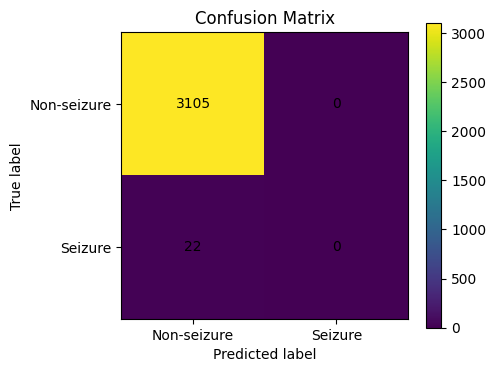

<Figure size 640x480 with 0 Axes>

In [10]:
# -----------------------------
# 9. 画 confusion matrix
# -----------------------------
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Non-seizure", "Seizure"])
plt.yticks([0, 1], ["Non-seizure", "Seizure"])
plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()
plt.savefig("confusion_matrix.png")

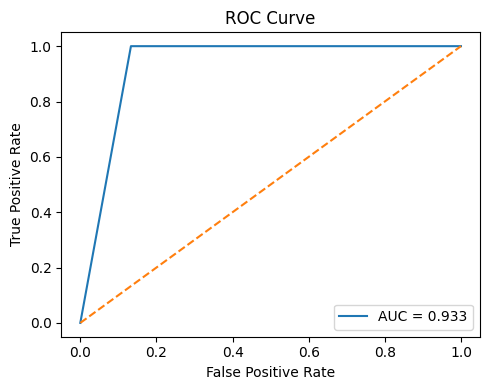

<Figure size 640x480 with 0 Axes>

In [11]:
# -----------------------------
# 10. 画 ROC curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("ROC.png")

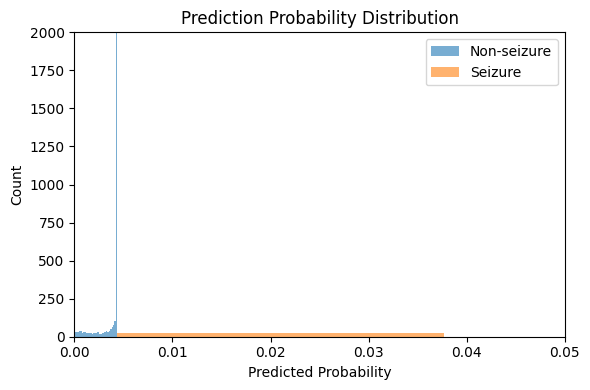

<Figure size 640x480 with 0 Axes>

In [12]:
# -----------------------------
# 11. 画 probability distribution
# -----------------------------
plt.figure(figsize=(6, 4))
plt.hist(y_prob[y_test == 0], bins=30, alpha=0.6, label="Non-seizure")
plt.hist(y_prob[y_test == 1], bins=30, alpha=0.6, label="Seizure")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.xlim(0, 0.05)
plt.ylim(0,2000)
plt.title("Prediction Probability Distribution")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("probability_distribution.png")

In [13]:
# -----------------------------
# 12. 看预测为 seizure 的窗口
# -----------------------------
predicted_positive = np.where(y_pred == 1)[0]

print("Predicted seizure windows:")
for idx in predicted_positive[:20]:
    m = meta_test[idx]
    print(
        m["file"],
        f"{m['start_sec']:.1f}-{m['end_sec']:.1f}s",
        "true =", y_test[idx],
        "prob =", round(float(y_prob[idx]), 4)
    )

Predicted seizure windows:
